# Notebook n°6: Milestone 3 (M3) FRC-State Classification from Audio + Resolution Sweep

**Pipeline stage:** the productive reframing after the %RC-regression negative result (notebook n°5). Instead of predicting *continuous* %RC, we ask a better-posed binary question: is a phonation frame **above** or **below** the FRC crossing? Level 3 (notebook n°4) showed F0 is reliably elevated below FRC, so FRC state should be acoustically accessible.

**Scripts reproduced**
| Script | Role |
|--------|------|
| `scripts/analyze_frc_classification.py` | pooled / F0-only / per-subject / stratified classification, feature importance |
| `scripts/analyze_frc_window_sweep.py` | AUC vs temporal aggregation window (resolution↔accuracy trade-off) |

> **Plot types:** per-subject AUC histogram, signed feature-importance bar, AUC-comparison bar, resolution-sweep curve (log-x with reference lines).
>
> ⚠️ Requires scikit-learn.

**Summary.**\
Classifying above- vs below-FRC state from acoustics is modestly above chance: pooled AUC ≈ 0.66 (F0 alone ≈ 0.62), per-subject median ≈ 0.53 (near chance).\
It is strongest in the elderly strata, where the rib-cage compartment is most engaged (consistent with the large `%RC` FRC-crossing effect in notebook n°4).\
So FRC state leaves a weak but real, F0-dominated acoustic signature, most detectable in older speakers.

## 0. Setup

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))

import analyze_frc_classification as clf
import analyze_frc_window_sweep as sweep
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
META_PATH  = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
print("FRC tasks:", clf.FRC_TASKS)

FRC tasks: ['a_2', 'a_3', 'a_7']


## 1. Build the labelled, subject-standardized frame dataset
Maximum-phonation tasks `a_2`, `a_3`, `a_7` (37,120 voiced frames, 36 subjects).\
Each voiced frame of a sustained recording is labelled `below_frc` (1) or `above_frc` (0) at the FRC crossing; features are z-scored within subject (removing baseline differences, isolating the within-subject FRC signal).

In [2]:

metadata = clf.load_metadata(META_PATH)
frames, z_features = clf.build_labeled_dataset(PAIRED_DIR, metadata)
print(f"{len(frames):,} voiced frames | {frames['subject_id'].nunique()} subjects | "
      f"below-FRC fraction={frames['below_frc'].mean():.2f}")
print("features:", [f.replace('_z','') for f in z_features])

2026-06-11 16:26:54,209 - analyze_frc_classification - INFO - Labelled dataset: 37120 voiced frames, 36 subjects, below-FRC fraction = 0.52


37,120 voiced frames | 36 subjects | below-FRC fraction=0.52
features: ['f0', 'energy', 'spectral_centroid', 'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12']


## 2. Classification across framings
Maximum-phonation tasks `a_2`, `a_3`, `a_7`.\
ROC-AUC under leave-one-subject-out CV: pooled (all features), pooled (F0 only, to test whether F0 is the carrier), and per-subject (leave-one-recording-out).

In [3]:

pooled_auc, pooled_bacc, _ = clf.grouped_auc(frames, z_features, 'subject_id')
f0_z = [c for c in z_features if c.startswith('f0')]
f0_auc, f0_bacc, _ = clf.grouped_auc(frames, f0_z, 'subject_id')
per_subj = clf.per_subject_auc(frames, z_features)
per_subj_median = per_subj['auc'].median()
strat = {}
for cell in ['YM','YF','EM','EF']:
    sub = frames[frames['demographic']==cell]
    if sub['subject_id'].nunique() >= 3:
        strat[cell], _, _ = clf.grouped_auc(sub, z_features, 'subject_id')
print(f"pooled(all)={pooled_auc:.3f} | pooled(F0)={f0_auc:.3f} | per-subject median={per_subj_median:.3f}")
print("stratified:", {k: round(v,3) for k,v in strat.items()})

pooled(all)=0.664 | pooled(F0)=0.623 | per-subject median=0.548
stratified: {'YM': 0.587, 'YF': 0.596, 'EM': 0.74, 'EF': 0.748}


### 2a. Per-subject AUC distribution
Maximum-phonation tasks `a_2`, `a_3`, `a_7`, per subject.\
Leave-one-recording-out AUC within each subject; the dotted line is chance (0.5).

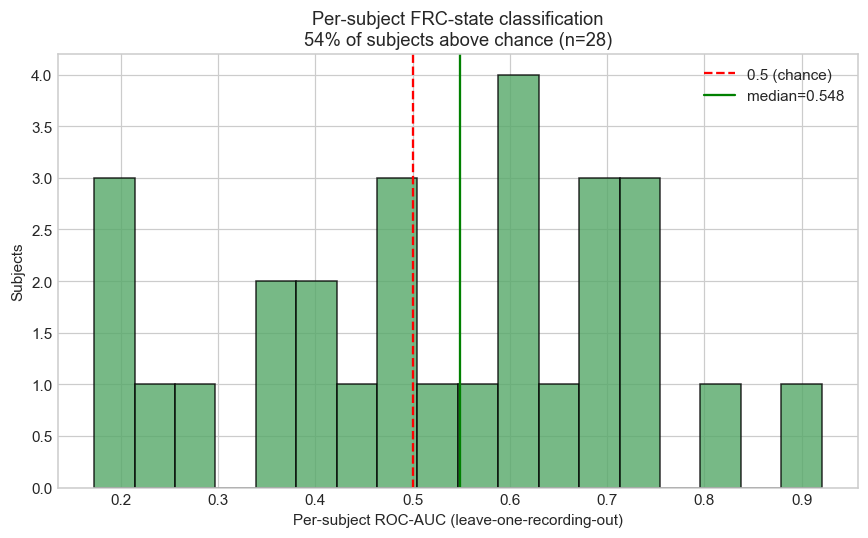

In [4]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(per_subj['auc'], bins=18, color='#55a868', alpha=0.8, edgecolor='black')
ax.axvline(0.5, color='red', ls='--', label='0.5 (chance)')
ax.axvline(per_subj['auc'].median(), color='green', label=f"median={per_subj['auc'].median():.3f}")
frac = (per_subj['auc'] > 0.5).mean()
ax.set_xlabel('Per-subject ROC-AUC (leave-one-recording-out)'); ax.set_ylabel('Subjects')
ax.set_title(f'Per-subject FRC-state classification\n{frac:.0%} of subjects above chance (n={len(per_subj)})')
ax.legend(); plt.tight_layout(); plt.show()

**Observations:**\
Maximum-phonation tasks `a_2`, `a_3`, `a_7`, per subject.\
Per-subject FRC-state AUC clusters around 0.53 (near chance) with a long tail.\
Individually, audio barely separates above-FRC from below-FRC frames.

### 2b. Feature importance
Maximum-phonation tasks `a_2`, `a_3`, `a_7`, pooled.\
Pooled logistic-regression coefficients on subject-standardized features. A positive value pushes toward "below FRC"; F0 is expected to dominate (consistent with Level 3).

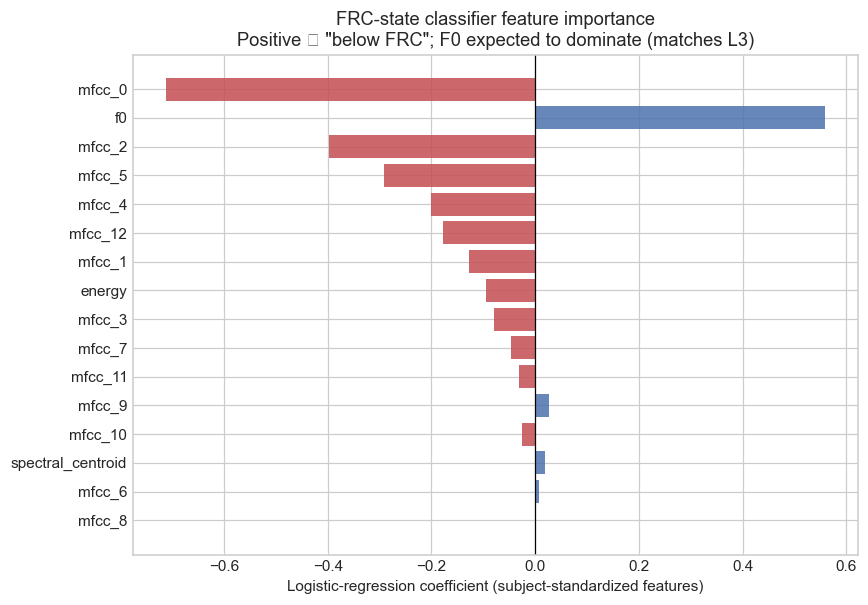

In [5]:

pipe = make_pipeline(StandardScaler(), clf._logreg())
pipe.fit(frames[z_features].values, frames['below_frc'].values)
coefs = pipe.named_steps['logisticregression'].coef_[0]
order = np.argsort(np.abs(coefs))
labels = [z_features[i].replace('_z','') for i in order]; vals = coefs[order]
colors = ['#c44e52' if v < 0 else '#4c72b0' for v in vals]
fig, ax = plt.subplots(figsize=(8, max(4, 0.35*len(z_features))))
ax.barh(range(len(vals)), vals, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8); ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels)
ax.set_xlabel('Logistic-regression coefficient (subject-standardized features)')
ax.set_title('FRC-state classifier feature importance\nPositive ⇒ "below FRC"; F0 expected to dominate (matches L3)')
plt.tight_layout(); plt.show()

**Observations:**\
Maximum-phonation tasks `a_2`, `a_3`, `a_7`, pooled.\
F0 dominates the classifier (F0-only AUC ≈ full model); other features add little.\
The weak FRC signature is essentially a pitch effect (F0 rises below FRC).

### 2c. AUC comparison across framings
Maximum-phonation tasks `a_2`, `a_3`, `a_7`.

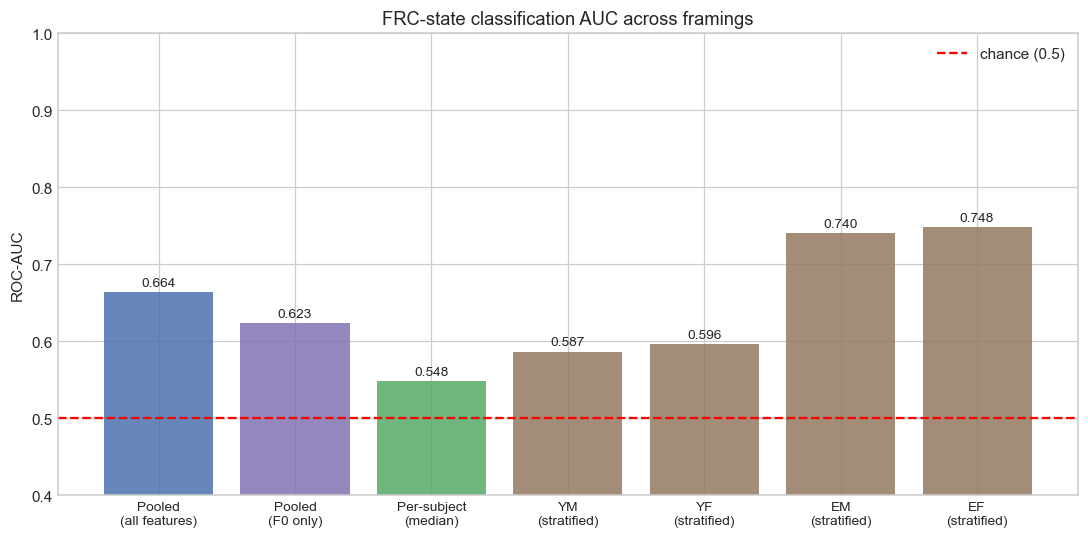

In [6]:

labels = ['Pooled\n(all features)', 'Pooled\n(F0 only)', 'Per-subject\n(median)'] + [f'{k}\n(stratified)' for k in strat]
values = [pooled_auc, f0_auc, per_subj_median] + list(strat.values())
colors = ['#4c72b0', '#8172b3', '#55a868'] + ['#937860']*len(strat)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(values)), values, color=colors, alpha=0.85)
ax.axhline(0.5, color='red', ls='--', label='chance (0.5)')
ax.set_ylim(0.4, 1.0); ax.set_xticks(range(len(values))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('ROC-AUC'); ax.set_title('FRC-state classification AUC across framings'); ax.legend()
for i, v in enumerate(values):
    if not np.isnan(v): ax.text(i, v+0.008, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Observations:**\
Maximum-phonation tasks `a_2`, `a_3`, `a_7`.\
Pooled AUC ≈ 0.66 beats per-subject (0.53) because pooling exploits between-subject F0 and FRC structure.\
The honest within-subject signal is weaker.

## 3. Resolution vs accuracy sweep
Maximum-phonation tasks `a_2`, `a_3`, `a_7` (73 recordings).\
Frame-level AUC (~0.65) and the recording-level sign-consistency ceiling (~0.84) are two points; this sweep fills in the curve by classifying FRC state at a range of temporal aggregation windows.

In [7]:

records, feats = sweep.build_recordings(PAIRED_DIR, metadata)
results = []
for w_sec in sweep.WINDOW_SIZES_SEC:
    w_frames = max(1, round(w_sec * sweep.FPS))
    X, y, g = sweep.build_windows(records, w_frames)
    auc, bacc, n = sweep.classify_auc(X, y, g)
    results.append(dict(window_sec=w_sec, auc=auc, n_windows=n))
Xw, yw, gw = sweep.build_windows(records, 0, whole_half=True)
whole_auc, _, _ = sweep.classify_auc(Xw, yw, gw)
res = pd.DataFrame(results)
display(res.round(3))
print(f"whole-half AUC = {whole_auc:.3f}")

2026-06-11 16:27:01,274 - analyze_frc_window_sweep - INFO - Recordings: 73 from 36 subjects, 16 features


,window_sec,auc,n_windows
0,0.015,0.664,37120
1,0.100,0.668,5325
2,0.250,0.680,2239
3,0.500,0.655,1186
4,1.000,0.669,617
5,2.000,0.694,356


whole-half AUC = 0.724


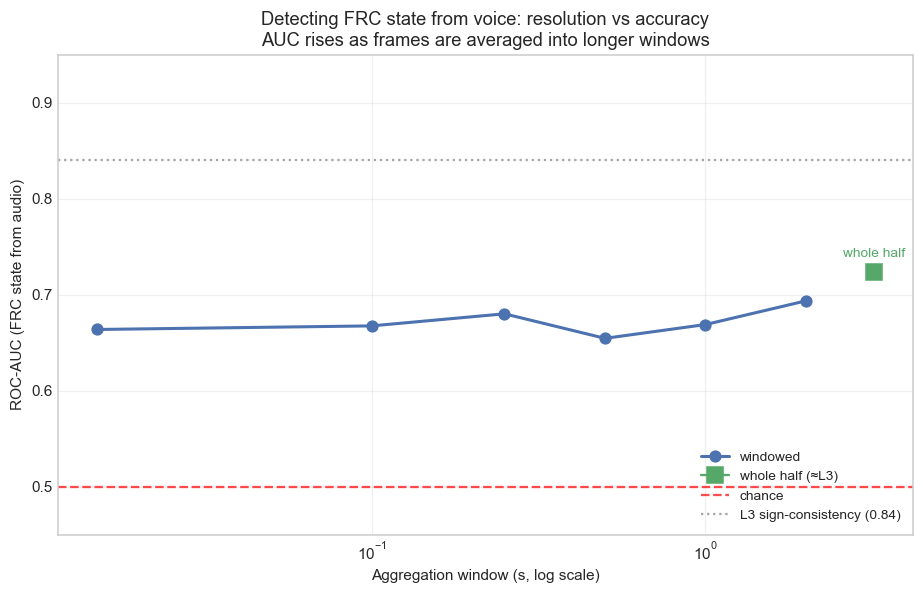

In [8]:

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(res['window_sec'], res['auc'], marker='o', color='#4c72b0', lw=2, ms=7, label='windowed')
x_whole = res['window_sec'].max() * 1.6
ax.plot(x_whole, whole_auc, marker='s', ms=10, color='#55a868', label='whole half (≈L3)')
ax.annotate('whole half', (x_whole, whole_auc), textcoords='offset points', xytext=(0, 10),
            ha='center', fontsize=9, color='#55a868')
ax.axhline(0.5, color='red', ls='--', alpha=0.7, label='chance')
ax.axhline(0.84, color='gray', ls=':', alpha=0.7, label='L3 sign-consistency (0.84)')
ax.set_xscale('log'); ax.set_xlabel('Aggregation window (s, log scale)'); ax.set_ylabel('ROC-AUC (FRC state from audio)')
ax.set_ylim(0.45, 0.95)
ax.set_title('Detecting FRC state from voice: resolution vs accuracy\nAUC rises as frames are averaged into longer windows')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Observations:**\
Maximum-phonation tasks `a_2`, `a_3`, `a_7`.\
AUC is flat across window sizes (~0.62 to 0.65) but jumps to ~0.72 for the whole-half split.\
Coarser, breath-scale framing carries more FRC information than any single frame.\
FRC state is a slow, breath-level property.

## Recap
FRC state **is** decodable from voice (modestly per frame, strongly once aggregated), unlike continuous %RC. The sweep gives a single defensible resolution-vs-accuracy curve.

Full scripts:
```bash
python scripts/analyze_frc_classification.py --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir results/M3_frc_classification
python scripts/analyze_frc_window_sweep.py   --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir results/M3_frc_classification
```